In [17]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

In [18]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

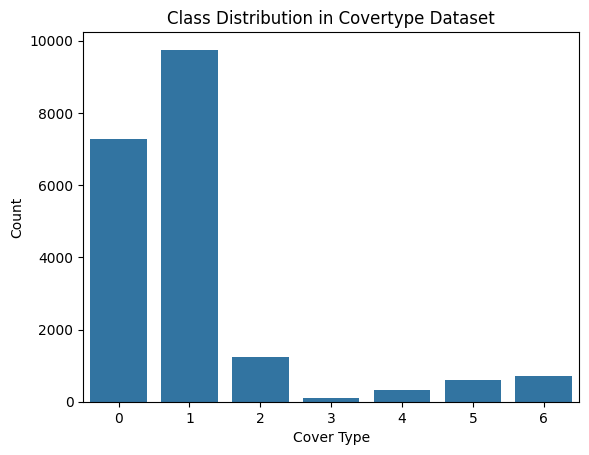

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

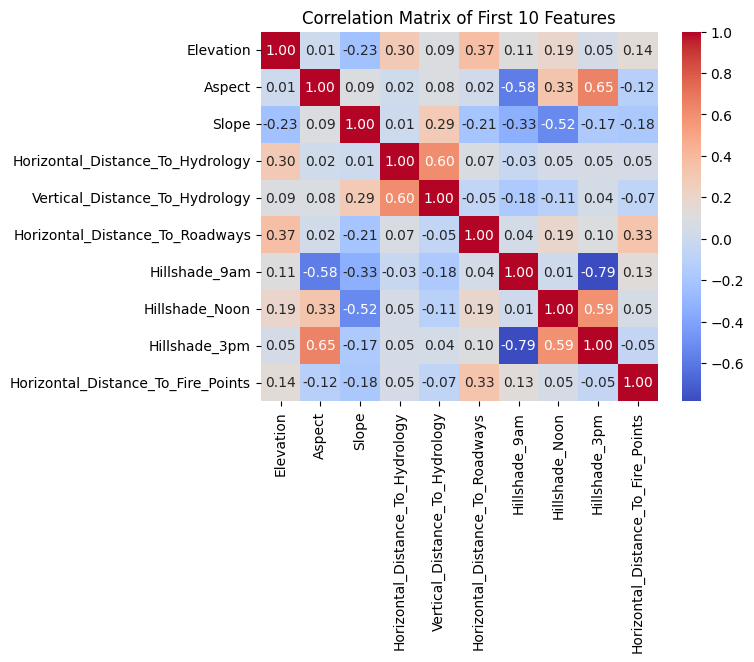

In [20]:
# Select first 10 features for simplicity
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()

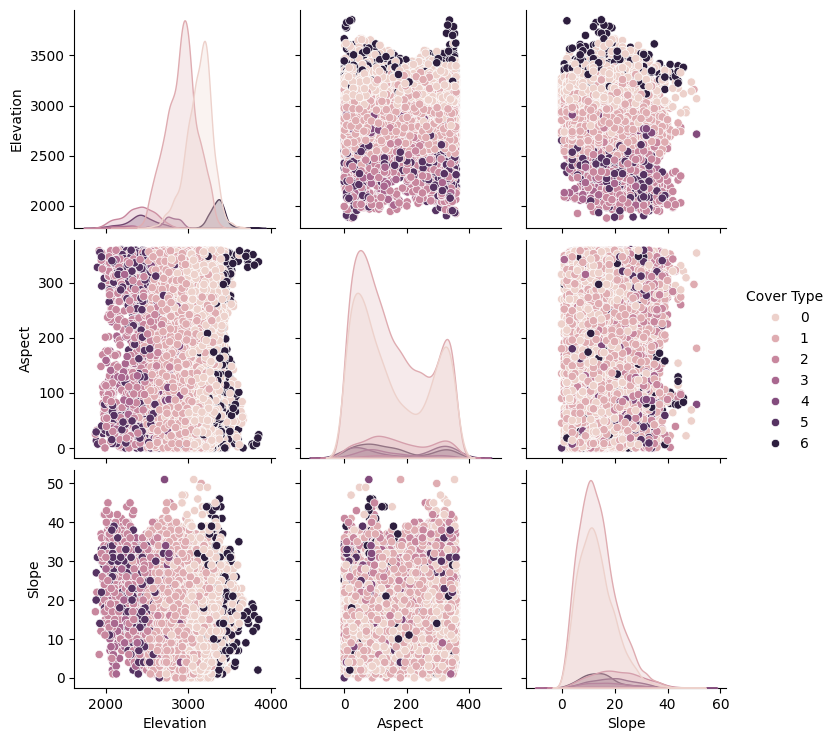

In [21]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

In [22]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


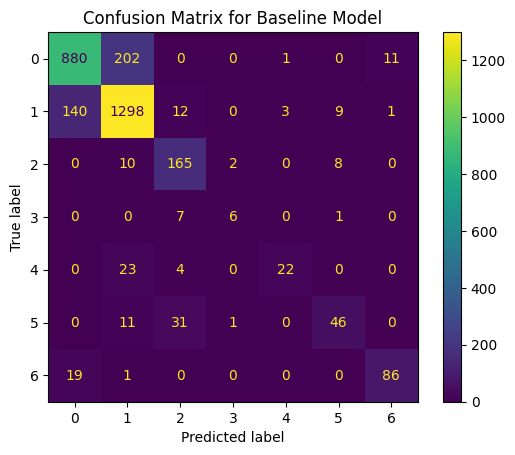

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

In [24]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import numpy as np

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'task_type': 'GPU',
        'loss_function': 'MultiClass'
    }

    # TODO: 
    # 1. Train CatBoost using params
    # 2. Return validation accuracy score as result
    # Area for improvement: use Cross-Validation instead of a single train/val split.
    model = CatBoostClassifier(**params)
    
    scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    
    return np.mean(scores)

In [26]:
# Create the study
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db' 
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction='maximize',
    load_if_exists=True
)
study.optimize(objective, n_trials=20)  # Run 20 trials

[I 2026-04-01 10:39:20,094] A new study created in RDB with name: catboost_optimization


0:	learn: 1.8834219	total: 88.4ms	remaining: 11.2s
1:	learn: 1.8274245	total: 100ms	remaining: 6.33s
2:	learn: 1.7758515	total: 112ms	remaining: 4.67s
3:	learn: 1.7288958	total: 123ms	remaining: 3.82s
4:	learn: 1.6853925	total: 134ms	remaining: 3.31s
5:	learn: 1.6445100	total: 145ms	remaining: 2.95s
6:	learn: 1.6066218	total: 156ms	remaining: 2.69s
7:	learn: 1.5711629	total: 167ms	remaining: 2.5s
8:	learn: 1.5379241	total: 178ms	remaining: 2.35s
9:	learn: 1.5067881	total: 190ms	remaining: 2.24s
10:	learn: 1.4771764	total: 202ms	remaining: 2.15s
11:	learn: 1.4494026	total: 214ms	remaining: 2.06s
12:	learn: 1.4225519	total: 225ms	remaining: 1.99s
13:	learn: 1.3969041	total: 236ms	remaining: 1.92s
14:	learn: 1.3724054	total: 246ms	remaining: 1.85s
15:	learn: 1.3497717	total: 256ms	remaining: 1.79s
16:	learn: 1.3279551	total: 266ms	remaining: 1.74s
17:	learn: 1.3072590	total: 278ms	remaining: 1.7s
18:	learn: 1.2875806	total: 289ms	remaining: 1.66s
19:	learn: 1.2685657	total: 299ms	remainin

[I 2026-04-01 10:39:27,676] Trial 0 finished with value: 0.7436998687119348 and parameters: {'iterations': 128, 'learning_rate': 0.02104788994311223, 'depth': 8, 'bagging_temperature': 0.5642367954365065, 'l2_leaf_reg': 0.4154111183095342, 'random_strength': 0.08194909963116911}. Best is trial 0 with value: 0.7436998687119348.


122:	learn: 0.6378288	total: 1.45s	remaining: 58.9ms
123:	learn: 0.6358625	total: 1.46s	remaining: 47.2ms
124:	learn: 0.6339686	total: 1.48s	remaining: 35.4ms
125:	learn: 0.6319969	total: 1.49s	remaining: 23.6ms
126:	learn: 0.6299938	total: 1.5s	remaining: 11.8ms
127:	learn: 0.6281626	total: 1.51s	remaining: 0us
0:	learn: 1.8119212	total: 5.39ms	remaining: 2.84s
1:	learn: 1.7050824	total: 9.95ms	remaining: 2.62s
2:	learn: 1.6170882	total: 13.7ms	remaining: 2.39s
3:	learn: 1.5416632	total: 17.4ms	remaining: 2.29s
4:	learn: 1.4764529	total: 21.2ms	remaining: 2.22s
5:	learn: 1.4189325	total: 24.9ms	remaining: 2.17s
6:	learn: 1.3681810	total: 28.4ms	remaining: 2.12s
7:	learn: 1.3226493	total: 32.1ms	remaining: 2.09s
8:	learn: 1.2816804	total: 35.8ms	remaining: 2.07s
9:	learn: 1.2449114	total: 39.5ms	remaining: 2.05s
10:	learn: 1.2107698	total: 43.2ms	remaining: 2.04s
11:	learn: 1.1801283	total: 46.8ms	remaining: 2.02s
12:	learn: 1.1511428	total: 50.5ms	remaining: 2s
13:	learn: 1.1242221	to

[I 2026-04-01 10:39:34,625] Trial 1 finished with value: 0.7702501238574436 and parameters: {'iterations': 529, 'learning_rate': 0.04984598752388927, 'depth': 4, 'bagging_temperature': 0.4757463590938681, 'l2_leaf_reg': 0.6632105078136051, 'random_strength': 3.24211461568707e-07}. Best is trial 1 with value: 0.7702501238574436.


...

0:	learn: 1.7323567	total: 17.1ms	remaining: 6.65s
1:	learn: 1.5814034	total: 34.8ms	remaining: 6.73s
2:	learn: 1.4637904	total: 50.9ms	remaining: 6.55s
3:	learn: 1.3691608	total: 69ms	remaining: 6.64s
4:	learn: 1.2884991	total: 88.4ms	remaining: 6.79s
5:	learn: 1.2190354	total: 105ms	remaining: 6.71s
6:	learn: 1.1606987	total: 122ms	remaining: 6.63s
7:	learn: 1.1080271	total: 141ms	remaining: 6.71s
8:	learn: 1.0622297	total: 157ms	remaining: 6.65s
9:	learn: 1.0213816	total: 174ms	remaining: 6.61s
10:	learn: 0.9847008	total: 192ms	remaining: 6.59s
11:	learn: 0.9519395	total: 208ms	remaining: 6.55s
12:	learn: 0.9224712	total: 224ms	remaining: 6.48s
13:	learn: 0.8952574	total: 241ms	remaining: 6.45s
14:	learn: 0.8700836	total: 260ms	remaining: 6.47s
15:	learn: 0.8463681	total: 280ms	remaining: 6.52s
16:	learn: 0.8247947	total: 296ms	remaining: 6.48s
17:	learn: 0.8056321	total: 312ms	remaining: 6.42s
18:	learn: 0.7881454	total: 328ms	remaining: 6.38s
19:	learn: 0.7707179	total: 345ms	rema

[I 2026-04-01 10:46:43,204] Trial 18 finished with value: 0.8350999716740836 and parameters: {'iterations': 389, 'learning_rate': 0.07266159334364872, 'depth': 9, 'bagging_temperature': 0.7286851211018864, 'l2_leaf_reg': 0.2301925400832694, 'random_strength': 0.0028446584782502405}. Best is trial 11 with value: 0.8445502867370882.


0:	learn: 1.5773942	total: 8.25ms	remaining: 3.82s
1:	learn: 1.3799487	total: 16.2ms	remaining: 3.75s
2:	learn: 1.2438551	total: 25ms	remaining: 3.85s
3:	learn: 1.1435393	total: 32.6ms	remaining: 3.75s
4:	learn: 1.0651208	total: 40.7ms	remaining: 3.73s
5:	learn: 1.0011162	total: 48.5ms	remaining: 3.71s
6:	learn: 0.9486394	total: 56.6ms	remaining: 3.69s
7:	learn: 0.9044508	total: 64.6ms	remaining: 3.68s
8:	learn: 0.8684779	total: 72.6ms	remaining: 3.67s
9:	learn: 0.8369730	total: 80.8ms	remaining: 3.67s
10:	learn: 0.8082924	total: 89ms	remaining: 3.67s
11:	learn: 0.7860681	total: 96.7ms	remaining: 3.64s
12:	learn: 0.7638555	total: 106ms	remaining: 3.67s
13:	learn: 0.7428560	total: 115ms	remaining: 3.69s
14:	learn: 0.7238134	total: 123ms	remaining: 3.69s
15:	learn: 0.7089130	total: 132ms	remaining: 3.7s
16:	learn: 0.6942638	total: 141ms	remaining: 3.71s
17:	learn: 0.6824540	total: 150ms	remaining: 3.73s
18:	learn: 0.6709663	total: 159ms	remaining: 3.71s
19:	learn: 0.6618145	total: 167ms	

[I 2026-04-01 10:46:56,686] Trial 19 finished with value: 0.8296001191539583 and parameters: {'iterations': 464, 'learning_rate': 0.13747989133567495, 'depth': 7, 'bagging_temperature': 0.7901286514240382, 'l2_leaf_reg': 1.721892938333304, 'random_strength': 0.3260070842961168}. Best is trial 11 with value: 0.8445502867370882.


459:	learn: 0.2159506	total: 4.46s	remaining: 38.8ms
460:	learn: 0.2156944	total: 4.47s	remaining: 29.1ms
461:	learn: 0.2154145	total: 4.48s	remaining: 19.4ms
462:	learn: 0.2149776	total: 4.49s	remaining: 9.7ms
463:	learn: 0.2146449	total: 4.5s	remaining: 0us


In [27]:
# Retrieve the best trial from the study
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 11
Best Validation Accuracy: 0.8446
Best Hyperparameters Found:
  iterations: 426
  learning_rate: 0.19251387331331937
  depth: 10
  bagging_temperature: 0.6244460668254578
  l2_leaf_reg: 0.012162187064173317
  random_strength: 5.426685982451451e-05


Przy depth osiągnęliśmy maksymalną wartość. Oznacza to, że model preferuje bardzeij skomplikowane drzewa.

Na uwagę zasługuje też dosyć wysoki learning rate.

Random strength jest bliski 0, model nie korzysta z szumu.

In [28]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_full, y_train_full)

0:	learn: 1.4099076	total: 75.3ms	remaining: 32s
1:	learn: 1.1890025	total: 140ms	remaining: 29.8s
2:	learn: 1.0413975	total: 214ms	remaining: 30.2s
3:	learn: 0.9382786	total: 278ms	remaining: 29.3s
4:	learn: 0.8639318	total: 341ms	remaining: 28.7s
5:	learn: 0.7972943	total: 406ms	remaining: 28.4s
6:	learn: 0.7465514	total: 474ms	remaining: 28.4s
7:	learn: 0.7025819	total: 550ms	remaining: 28.7s
8:	learn: 0.6688647	total: 624ms	remaining: 28.9s
9:	learn: 0.6393838	total: 691ms	remaining: 28.7s
10:	learn: 0.6096490	total: 754ms	remaining: 28.4s
11:	learn: 0.5884432	total: 818ms	remaining: 28.2s
12:	learn: 0.5694622	total: 884ms	remaining: 28.1s
13:	learn: 0.5530955	total: 956ms	remaining: 28.1s
14:	learn: 0.5393274	total: 1.04s	remaining: 28.5s
15:	learn: 0.5272380	total: 1.11s	remaining: 28.4s
16:	learn: 0.5129906	total: 1.17s	remaining: 28.2s
17:	learn: 0.5016218	total: 1.24s	remaining: 28s
18:	learn: 0.4915166	total: 1.3s	remaining: 27.8s
19:	learn: 0.4808868	total: 1.36s	remaining: 

CatBoostClassifier(bagging_temperature=0.6244460668254578, depth=10, iterations=426, l2_leaf_reg=0.012162187064173317, learning_rate=0.19251387331331937, random_state=42, random_strength=5.426685982451451e-05)

--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 85.63%
Improvement due to HPO: 2.20%
Confusion Matrix for Final Optimized Model (on Test Set):


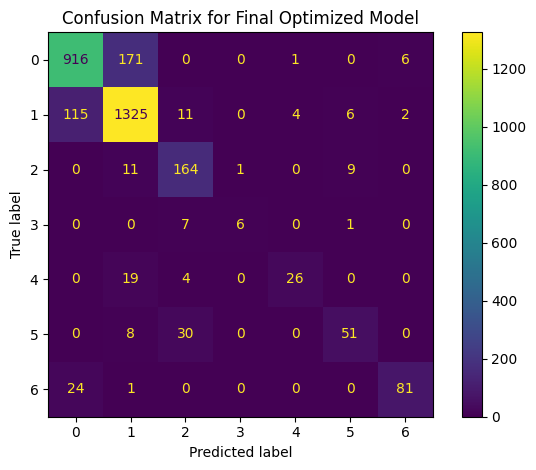

In [29]:
y_pred_test = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

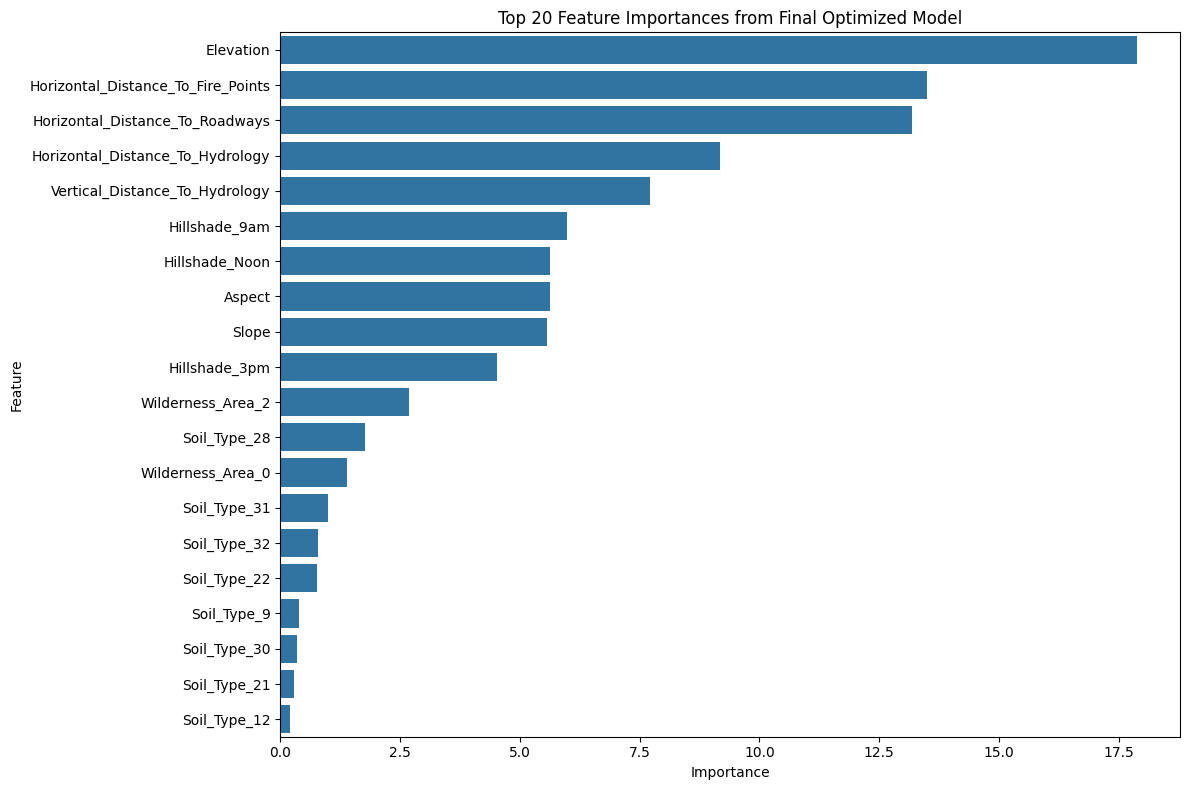

In [30]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()